In [1]:
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text
import pandas as pd 

In [14]:
df = pd.read_csv('C:\\Users\\User\\Documents\\GitHub\\proutectapp\\mobile-application\\python-files\\spam_or_not_spam.csv')

# Assigns 1 to positive feedback and 0 to negative feedback - creates a new column in original dataframe
# df['safe'] = df['Sentiment'].apply(lambda x: 1 if x=='Positive' else 0)

df['label'].value_counts

KeyError: 'Sentiment'

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
# Creates train and test set
X_train, X_test, y_train, y_test = train_test_split(df['Feedback'], df['safe'], stratify=df['safe'])

# Must download pre-trained models for semantic analysis
bert_preprocess = hub.KerasLayer("https://www.kaggle.com/models/tensorflow/bert/frameworks/TensorFlow2/variations/en-uncased-preprocess/versions/3")
bert_encoder = hub.KerasLayer("https://www.kaggle.com/models/tensorflow/bert/frameworks/TensorFlow2/variations/en-uncased-l-12-h-768-a-12/versions/4")

# Sequential vs Functional Model in Keras.. read article


In [5]:
def get_feedback_embedding(feedback):

    # Preprocessing stage 
    prepocessed_feedback = bert_preprocess(feedback)

    # Encoding stage
    return bert_encoder(prepocessed_feedback)['pooled_output']

In [6]:
# Input layer of NN
text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name="text")
preprocessed_text = bert_preprocess(text_input)
outputs = bert_encoder(preprocessed_text)

In [7]:
# Neural Network layers
l = tf.keras.layers.Dropout(0.1, name='dropout')(outputs['pooled_output'])
l = tf.keras.layers.Dense(1, activation='sigmoid', name='output')(l)


# Construct final model
model = tf.keras.Model(inputs=[text_input], outputs=[l])

In [8]:
# Training parameters - 769 as input parameters are 768.
METRICS = [
    tf.keras.metrics.BinaryAccuracy(name='accuracy'),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name='recall')
]

optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)
model.compile(optimizer=optimizer,
              loss = 'binary_crossentropy',
              metrics = METRICS)


In [9]:

model.fit(X_train, y_train, epochs=10)
model.evaluate(X_test, y_test)

y_predicted = model.predict(X_test)
y_predicted = y_predicted.flatten()

Epoch 1/10
6/6 [==============================] - 36s 5s/step - loss: 0.7108 - accuracy: 0.5205 - precision: 0.8000 - recall: 0.0471
Epoch 2/10
6/6 [==============================] - 30s 5s/step - loss: 0.7108 - accuracy: 0.5088 - precision: 0.5385 - recall: 0.0824
Epoch 3/10
6/6 [==============================] - 31s 5s/step - loss: 0.7302 - accuracy: 0.4912 - precision: 0.4444 - recall: 0.0941
Epoch 4/10
6/6 [==============================] - 32s 5s/step - loss: 0.7084 - accuracy: 0.5146 - precision: 0.5625 - recall: 0.1059
Epoch 5/10
6/6 [==============================] - 33s 5s/step - loss: 0.6977 - accuracy: 0.5556 - precision: 0.7368 - recall: 0.1647
Epoch 6/10
6/6 [==============================] - 32s 5s/step - loss: 0.6915 - accuracy: 0.5380 - precision: 0.6667 - recall: 0.1412
Epoch 7/10
6/6 [==============================] - 33s 5s/step - loss: 0.7187 - accuracy: 0.4795 - precision: 0.4231 - recall: 0.1294
Epoch 8/10
6/6 [==============================] - 33s 5s/step - loss:

In [10]:
import numpy as np 
from sklearn.metrics import confusion_matrix, classification_report

In [11]:
y_predicted = np.where(y_predicted > 0.5, 1, 0)
y_predicted
cm = confusion_matrix(y_test, y_predicted)
cm

array([[28,  1],
       [26,  2]], dtype=int64)

In [12]:
from matplotlib import pyplot as plt
import seaborn as sn

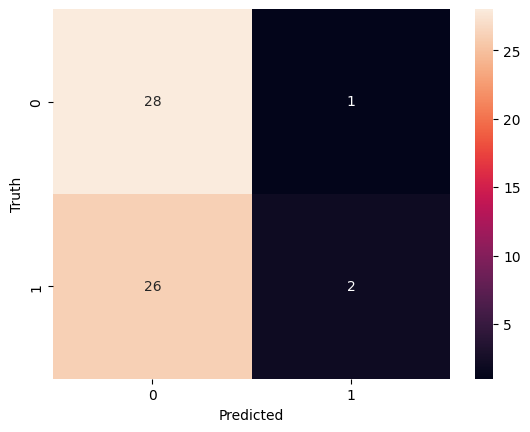

In [13]:
sn.heatmap(cm, annot = True, fmt = 'd')
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()